In [32]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
    GoogleGenerativeAIEmbeddings,
)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

## **Xử lý phần tải file, chia chunks, lưu vào vector stores (FAISS)**

In [33]:
# 1) Load the PDF document
docs = (
    PyPDFLoader("../documents/AI_Engineer_Roadmap_2026.pdf").load()
)

print("Pages in document:", len(docs))

Pages in document: 19


In [34]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(
    chunk_size=900, 
    chunk_overlap=150
).split_documents(docs)

print("Chunks:", len(chunks))

Chunks: 32


In [35]:
# 3) Embedding
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
)

In [36]:
# 4) Create FAISS vector store
vector_store = FAISS.from_documents(
    chunks,
    embeddings
)

vector_store.save_local("vector_store")

In [37]:
# 5) Create retriever
retriever = vector_store.as_retriever(
    search_kwargs={"k": 3}
)

## **Xử lý LLM, Prompts và State**

In [38]:
# 1) LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
)

In [39]:
# 2) Prompt template
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

In [40]:
# 3) Create a state graph
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [ ]:
# 4) Retrieve node
def retrieve(state):
    query = state["question"]
    output = retriever.invoke(query)

    return {
        "docs": output
    }

In [46]:
print(docs[0].page_content)

codebasics.io 
 
1 
AI Engineer Roadmap 2026 
Following is the roadmap for AI Engineer, ML Engineer or Gen AI Engineer. It includes FREE 
learning resources for technical skills (or tool skills) and soft (or core) skills                        
This roadmap is designed based on the analysis of hundreds of AI jobs and our own experience of 
working on AI projects at AtliQ Technologies (https://www.atliq.com/) where we have worked on 
25+ AI projects in last two year alone. More than 90% of our clients at AtliQ are SMEs (Small to 
medium size enterprises) based in USA. 
Link of AI engineer jobs analysis: https://github.com/Codebasics-Content/job-
scrapper/blob/main/data/csv/new_scraped/data_visualizer.ipynb 
AI case studies at AtliQ: https://www.atliq.com/case-studies 
Link of our full YouTube video for this roadmap: https://youtu.be/zwUSZD3t_BU 
Find Your Suitability: Before you start your learning journey, it is important you find out if AI 
engineering career really suits your natural

In [42]:
# 5) Generate node
def generate(state):
    # Lấy nội dung của các documents
    context = ""

    for doc in state["docs"]:
        context += doc.page_content + "\n\n"

    # Chuẩn bị input cho prompt
    prompt_input = {
        "question": state["question"],
        "context": context
    }

    # Gọi LLM
    response = (prompt | llm).invoke(prompt_input)

    # Lấy text từ response
    answer = response.content

    if isinstance(answer, list):
        answer = answer[0]["text"]

    return {
        "answer": answer
    }

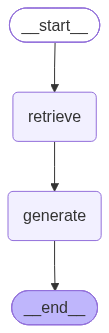

In [43]:
# 6) Create graph
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)

app = g.compile()
app

In [44]:
# 5) Run
res = app.invoke({
    "question": "Hãy tóm tắt các chương cần học để trở thành một AI Engineer", 
    "docs": [], 
    "answer": ""
})
print(res["answer"])

[Document(id='a30dd058-2f59-4e55-af4d-ea38e6315067', metadata={'producer': '3.0.30 (5.1.14)', 'creator': 'Microsoft Word', 'creationdate': '2025-11-25T22:44:28-08:00', 'author': 'Dhaval Patel', 'moddate': '2025-11-26T07:48:17+01:00', 'source': '../documents/AI_Engineer_Roadmap_2026.pdf', 'total_pages': 19, 'page': 17, 'page_label': '18'}, page_content='codebasics.io \n \n18 \nWeek 30, 31, 32: Azure or AWS ⛅ \n \n• Cloud skills (Azure or AWS) are essential especially for experienced AI engineer roles. \nWhen we analyzed AI engineer jobs, we found Azure to be at the top among all \ncloud providers when it comes to AI.  \n• For freshers, it is ok even if they do not learn cloud skills. Normally interviewers do \nnot expect cloud skills in a fresher job opening BUT if you know this skill then that \nwill bring unfair advantage for you. \n• Topics  \no Azure \n▪ Azure fundamentals: Resource groups, subscriptions, regions, storage, \nIAM \n▪ Compute and deployment services: azure functions, 